# Fold Change Analysis: S. aureus Survival with P. aeruginosa Mutants

This notebook analyzes the effect of spatial segregation patterns on *S. aureus* survival when co-cultured with different *P. aeruginosa* strains, relative to the ΔΔrhlApqsL control.

## Dataset
- **Experimental design**: Checkerboard co-cultures with four spatial arrangements (mixed, small, medium, big)
- **Measurement**: *S. aureus* survival probability after 1h tobramycin treatment  
- **Replicates**: 3 biological replicates per condition
- **Strains**: Wild-type, RHL+ (rhlAB overexpression), HQNO+ (pqsL overexpression), and ΔΔrhlApqsL control

## Analysis Approach
Paired analysis comparing each strain to ΔΔrhlApqsL within the same replicate, using geometric statistics appropriate for fold-change data on a log scale.

In [4]:
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# Load survival data from all three biological replicates
file_names = ['20251030.xlsx', '20251105.xlsx', '20251114.xlsx']

all_data = []
for i, fname in enumerate(file_names, start=1):
    df = pd.read_excel(fname)
    df_sa = df[(df['target'] == 'S. aureus') & (df['timepoint'] == 1)].copy()
    df_sa['replicate'] = i
    all_data.append(df_sa)
    print(f"✓ Loaded replicate {i}: {fname}")

# Combine replicates
survival_df = pd.concat(all_data, ignore_index=True)

# Map strain names to concise labels
partner_map = {
    'P. aeruginosa wt': 'wt',
    'P. aeruginosa ∆∆rhlApqsL': '∆∆',
    'P. aeruginosa pqsL+': 'HQNO+',
    'P. aeruginosa rhlAB+': 'RHL+'
}
survival_df['partner_label'] = survival_df['partner'].map(partner_map)

print(f"\n✓ Total observations: {len(survival_df)}")
print(f"✓ Strains: {sorted(survival_df['partner_label'].unique())}")
print(f"✓ Checkerboard patterns: {sorted(survival_df['checkerboard'].unique())}")

✓ Loaded replicate 1: 20251030.xlsx
✓ Loaded replicate 2: 20251105.xlsx
✓ Loaded replicate 3: 20251114.xlsx

✓ Total observations: 48
✓ Strains: ['HQNO+', 'RHL+', 'wt', '∆∆']
✓ Checkerboard patterns: ['big', 'medium', 'mixed', 'small']


## Figure 5C: Fold Change Relative to ΔΔrhlApqsL Control

Bar plot showing *S. aureus* survival for each strain relative to the ΔΔrhlApqsL control across four checkerboard patterns. Error bars represent geometric standard deviation (proper for log-scale data). Individual replicates are shown as black dots.

TypeError: 'module' object is not subscriptable

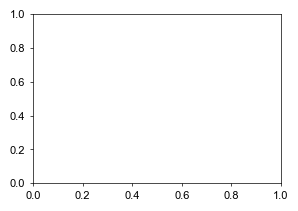

In [5]:
# Configure publication-quality style
matplotlib.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.width': 0.5,
    'ytick.major.size': 2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# Define analysis parameters
checker_order = ['mixed', 'small', 'medium', 'big']
groups_to_plot = ['wt', 'RHL+', 'HQNO+']
control_label = '∆∆'

color_map = {
    'wt': '#ffcc66',
    'RHL+': '#cc99ff',
    'HQNO+': '#669966',
}

# Calculate paired ratios (strain/ΔΔ within each replicate)
ratio_rows = []

for chk in checker_order:
    sub = survival_df[survival_df['checkerboard'] == chk].copy()
    replicates = sub['replicate'].unique()
    
    for rep in replicates:
        # Get ΔΔ value for this replicate
        dd_val = sub[(sub['partner_label'] == control_label) & (sub['replicate'] == rep)]['survival']
        
        if len(dd_val) == 0:
            continue
        
        dd_val = float(dd_val.iloc[0])
        
        # Calculate ratio for each strain
        for strain in groups_to_plot:
            strain_val = sub[(sub['partner_label'] == strain) & (sub['replicate'] == rep)]['survival']
            
            if len(strain_val) > 0:
                strain_val = float(strain_val.iloc[0])
                ratio = strain_val / dd_val
                ratio_rows.append({
                    'checkerboard': chk,
                    'strain': strain,
                    'replicate': rep,
                    'ratio': ratio,
                    'log_ratio': np.log(ratio)
                })

ratio_df = pd.DataFrame(ratio_rows)

# Calculate geometric mean and geometric SD (proper for log-scale data)
stats_list = []
for (chk, strain), group in ratio_df.groupby(['checkerboard', 'strain']):
    log_ratios = group['log_ratio'].values
    
    # Geometric mean = exp(mean of log)
    geo_mean = np.exp(np.mean(log_ratios))
    
    # Geometric SD = exp(SD of log)
    geo_sd = np.exp(np.std(log_ratios, ddof=1))
    
    # Asymmetric error bars on log scale
    lower = geo_mean / geo_sd
    upper = geo_mean * geo_sd
    
    stats_list.append({
        'checkerboard': chk,
        'strain': strain,
        'geo_mean': geo_mean,
        'geo_sd': geo_sd,
        'lower': lower,
        'upper': upper,
        'count': len(log_ratios)
    })

stats_df = pd.DataFrame(stats_list)
stats_df['checkerboard'] = pd.Categorical(stats_df['checkerboard'], categories=checker_order, ordered=True)
stats_df['strain'] = pd.Categorical(stats_df['strain'], categories=groups_to_plot, ordered=True)
stats_df = stats_df.sort_values(['checkerboard', 'strain'])

ratio_df['checkerboard'] = pd.Categorical(ratio_df['checkerboard'], categories=checker_order, ordered=True)
ratio_df['strain'] = pd.Categorical(ratio_df['strain'], categories=groups_to_plot, ordered=True)

# Create figure
fig, ax = plt.subplots(figsize=(3.2, 2.2))

x = np.arange(len(checker_order))
width = 0.24

for i, strain in enumerate(groups_to_plot):
    st = stats[stats['strain'] == strain].set_index('checkerboard').reindex(checker_order)
    
    geo_means = st['geo_mean'].to_numpy(dtype=float)
    lowers = st['lower'].to_numpy(dtype=float)
    uppers = st['upper'].to_numpy(dtype=float)
    
    # Bar positions
    x_pos = x + (i - (len(groups_to_plot)-1)/2) * width
    
    # Plot bars (geometric mean)
    ax.bar(x_pos, geo_means, width=width, color=color_map[strain],
           edgecolor='black', linewidth=0.5, label=strain, alpha=0.85, zorder=2)
    
    # Add asymmetric error bars (proper for log scale)
    lower_err = geo_means - lowers
    upper_err = uppers - geo_means
    
    ax.errorbar(x_pos, geo_means, yerr=[lower_err, upper_err],
                fmt='none', ecolor='black', elinewidth=0.5, 
                capsize=3, capthick=0.5, zorder=3)
    
    # Overlay individual replicate measurements
    for j, chk in enumerate(checker_order):
        subset = ratio_df[(ratio_df['checkerboard'] == chk) & (ratio_df['strain'] == strain)]
        if len(subset) > 0:
            x_jitter = np.random.normal(0, 0.03, size=len(subset))
            x_positions = np.full(len(subset), x_pos[j]) + x_jitter
            ax.scatter(x_positions, subset['ratio'].values, s=20, 
                      color='black', alpha=0.5, zorder=4, edgecolor='none')

# Format axes
ax.set_yscale('log')
ax.axhline(1, linestyle='--', linewidth=0.5, color='gray', alpha=0.7, zorder=1)

ax.set_xlabel('Segregation pattern', fontsize=8)
ax.set_ylabel('Fold change relative to ∆∆', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in checker_order], fontsize=8)

# Set y-axis limits
ymax = np.nanmax(stats['upper'].to_numpy(dtype=float))
ymax = max(ymax * 2.5, 3)
ax.set_ylim(1e-2, ymax)

# Clean appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.grid(False)
ax.legend(frameon=False, fontsize=8, loc='upper right', handlelength=1.2, handletextpad=0.4)

# Save and display
plt.tight_layout()
plt.savefig('5C_fold_change.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: 5C_fold_change.pdf")
print("\nGeometric statistics (proper for log-scale data):")
print(stats.to_string(index=False))

## Statistical Analysis: Paired T-Tests with Holm Correction

One-sample t-tests on log-transformed fold changes to determine whether each strain differs significantly from the ΔΔrhlApqsL control. P-values are corrected within each checkerboard pattern using Holm's step-down method.

**Null hypothesis (H₀)**: Geometric mean fold-change = 1 (no difference from ΔΔ)

In [6]:
# Perform one-sample t-tests on log-transformed ratios
results_list = []

for chk in checker_order:
    for strain in groups_to_plot:
        subset = ratio_df[(ratio_df['checkerboard'] == chk) & (ratio_df['strain'] == strain)]
        
        if len(subset) >= 3:
            log_ratios = subset['log_ratio'].values
            
            # One-sample t-test: H0: mean log-ratio = 0 (equivalent to fold-change = 1)
            t_stat, p_val = stats.ttest_1samp(log_ratios, 0)
            
            # Calculate geometric statistics
            geo_mean = np.exp(np.mean(log_ratios))
            geo_sd = np.exp(np.std(log_ratios, ddof=1))
            delta_log10 = np.mean(log_ratios) / np.log(10)
            
            results_list.append({
                'checkerboard': chk,
                'strain': strain,
                'n': len(log_ratios),
                'geometric_mean': geo_mean,
                'geometric_SD': geo_sd,
                'delta_log10': delta_log10,
                't_statistic': t_stat,
                'df': len(log_ratios) - 1,
                'p_value': p_val
            })
        else:
            print(f"[WARN] Insufficient data for {chk} - {strain}: n={len(subset)}")

results_df = pd.DataFrame(results_list)

# Apply Holm correction within each checkerboard
print("\n" + "="*70)
print("PAIRED T-TEST: STRAIN VS ΔΔ (HOLM CORRECTION WITHIN CHECKERBOARD)")
print("="*70)

for chk in checker_order:
    mask = results_df['checkerboard'] == chk
    p_vals = results_df.loc[mask, 'p_value'].values
    
    # Apply Holm correction
    reject, p_adjusted, _, _ = multipletests(p_vals, method='holm')
    results_df.loc[mask, 'p_holm'] = p_adjusted
    
    print(f"\n{chk.upper()}:")
    for strain, p_raw, p_adj in zip(results_df.loc[mask, 'strain'], p_vals, p_adjusted):
        print(f"  {strain:6s}: p_raw = {p_raw:.6f} → p_holm = {p_adj:.6f}")

# Add significance symbols
results_df['significance'] = results_df['p_holm'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)

# Display results
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print("\nMethod: One-sample t-test on log-transformed ratios (strain/ΔΔ)")
print("Correction: Holm-Bonferroni within each checkerboard")
print("H₀: Geometric mean fold-change = 1 (no difference from ΔΔ)")
print("\n" + "-"*70)

# Format for display
results_display = results_df.copy()
results_display['geometric_mean'] = results_display['geometric_mean'].round(3)
results_display['geometric_SD'] = results_display['geometric_SD'].round(3)
results_display['delta_log10'] = results_display['delta_log10'].round(3)
results_display['t_statistic'] = results_display['t_statistic'].round(3)
results_display['p_value'] = results_display['p_value'].apply(
    lambda x: f"{x:.6f}" if x >= 0.0001 else f"{x:.2e}"
)
results_display['p_holm'] = results_display['p_holm'].apply(
    lambda x: f"{x:.6f}" if x >= 0.0001 else f"{x:.2e}"
)

print(results_display.to_string(index=False))

# Summary of significant results
print("\n" + "="*70)
print("SIGNIFICANT RESULTS (p_holm < 0.05)")
print("="*70)

sig_results = results_df[results_df['p_holm'] < 0.05]

if len(sig_results) > 0:
    for _, row in sig_results.iterrows():
        print(f"\n{row['checkerboard'].upper()} - {row['strain']} vs ΔΔ:")
        print(f"  Geometric mean fold-change: {row['geometric_mean']:.3f}")
        print(f"  Effect size (Δlog₁₀): {row['delta_log10']:.3f}")
        print(f"  t({row['df']}) = {row['t_statistic']:.3f}")
        print(f"  p_holm = {row['p_holm']:.6f} {row['significance']}")
else:
    print("\nNo significant differences found after Holm correction.")

# Manuscript-ready reporting
print("\n" + "="*70)
print("MANUSCRIPT-READY TEXT")
print("="*70)

print("\n**Methods:**")
print("Paired t-tests compared each P. aeruginosa strain to the ΔΔrhlApqsL control")
print("within the same biological replicate. For each replicate, the survival ratio")
print("(strain/ΔΔ) was log-transformed. One-sample t-tests tested whether the mean")
print("log-ratio differed from zero (equivalent to fold-change ≠ 1). P-values were")
print("adjusted within each checkerboard using Holm's step-down correction for three")
print("planned comparisons (wt, RHL+, HQNO+ vs ΔΔ). n=3 biological replicates per condition.")

print("\n**Significant comparisons after Holm correction (α=0.05):**")
for chk in checker_order:
    sub = results_df[results_df['checkerboard'] == chk]
    sig_sub = sub[sub['p_holm'] < 0.05]
    
    if sig_sub.empty:
        print(f"  {chk}: none (all p_Holm ≥ 0.05)")
    else:
        parts = []
        for _, r in sig_sub.iterrows():
            parts.append(
                f"{r['strain']} (FC={r['geometric_mean']:.2f}, "
                f"t({r['df']})={r['t_statistic']:.2f}, "
                f"p={r['p_holm']:.3f}{r['significance']})"
            )
        print(f"  {chk}: " + "; ".join(parts))

checker_order = ["mixed", "small", "medium", "big"]
groups_to_plot = ["wt", "RHL+", "HQNO+"]
control_label = "∆∆"

outcome_col = "survival"
checker_col = "checkerboard"
group_col = "partner_label"
rep_col = "replicate"

df = survival_df.copy()
df[outcome_col] = pd.to_numeric(df[outcome_col], errors="coerce")
df = df.dropna(subset=[outcome_col, checker_col, group_col, rep_col])

# ========================================
# CALCULATE PAIRED RATIOS
# ========================================
ratio_rows = []

for chk in checker_order:
    sub = df[df[checker_col] == chk].copy()
    replicates = sub[rep_col].unique()
    
    for rep in replicates:
        # Get ΔΔ value for this replicate
        dd_val = sub[(sub[group_col] == control_label) & (sub[rep_col] == rep)][outcome_col]
        
        if len(dd_val) == 0:
            print(f"[WARN] No {control_label} for checkerboard={chk}, replicate={rep}")
            continue
        
        dd_val = float(dd_val.iloc[0])
        
        # For each strain, get the value for this same replicate
        for strain in groups_to_plot:
            strain_val = sub[(sub[group_col] == strain) & (sub[rep_col] == rep)][outcome_col]
            
            if len(strain_val) > 0:
                strain_val = float(strain_val.iloc[0])
                ratio = strain_val / dd_val
                ratio_rows.append({
                    "checkerboard": chk,
                    "strain": strain,
                    "replicate": rep,
                    "ratio": ratio,
                    "log_ratio": np.log(ratio)  # Natural log for t-test
                })

ratio_df = pd.DataFrame(ratio_rows)

# ========================================
# PERFORM PAIRED T-TESTS
# ========================================
results_list = []

for chk in checker_order:
    for strain in groups_to_plot:
        subset = ratio_df[(ratio_df["checkerboard"] == chk) & (ratio_df["strain"] == strain)]
        
        if len(subset) >= 3:
            log_ratios = subset["log_ratio"].values
            ratios = subset["ratio"].values
            
            # One-sample t-test on log(ratios): H0: mean = 0 (ratio = 1)
            t_stat, p_val = stats.ttest_1samp(log_ratios, 0)
            
            # Geometric statistics (proper for log-normal data)
            geo_mean = np.exp(np.mean(log_ratios))
            geo_sd = np.exp(np.std(log_ratios, ddof=1))
            
            # Delta in log10 space (for reporting)
            delta_log10 = np.mean(log_ratios) / np.log(10)
            
            results_list.append({
                "checkerboard": chk,
                "strain": strain,
                "n": len(ratios),
                "geometric_mean": geo_mean,
                "geometric_SD": geo_sd,
                "delta_log10": delta_log10,
                "t_statistic": t_stat,
                "df": len(ratios) - 1,
                "p_value": p_val
            })
        else:
            print(f"[WARN] Insufficient data for {chk} - {strain}: n={len(subset)}")

results_df = pd.DataFrame(results_list)

# ========================================
# APPLY HOLM CORRECTION WITHIN EACH CHECKERBOARD
# ========================================
print("\n" + "-"*80)
print("Applying Holm correction within each checkerboard...")
print("-"*80)

for chk in checker_order:
    mask = results_df["checkerboard"] == chk
    p_vals = results_df.loc[mask, "p_value"].values
    
    # Apply Holm correction
    reject, p_adjusted, alphacSidak, alphacBonf = multipletests(p_vals, method="holm")
    
    results_df.loc[mask, "p_holm"] = p_adjusted
    
    print(f"\n{chk.upper()}:")
    for strain, p_raw, p_adj in zip(results_df.loc[mask, "strain"], p_vals, p_adjusted):
        print(f"  {strain:6s}: p_raw = {p_raw:.6f} → p_holm = {p_adj:.6f}")

# Add significance symbols
results_df["significance"] = results_df["p_holm"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
)

# ========================================
# DISPLAY RESULTS
# ========================================
print("\n" + "="*80)
print("FINAL RESULTS: PAIRED T-TEST WITH HOLM CORRECTION")
print("="*80)
print("\nMethod: One-sample t-test on log-transformed ratios (strain/ΔΔ)")
print("Correction: Holm-Bonferroni within each checkerboard")
print("H₀: Geometric mean fold-change = 1 (no difference from ΔΔ)")
print("\n" + "-"*80)

# Format for display
results_display = results_df.copy()
results_display["geometric_mean"] = results_display["geometric_mean"].round(3)
results_display["geometric_SD"] = results_display["geometric_SD"].round(3)
results_display["delta_log10"] = results_display["delta_log10"].round(3)
results_display["t_statistic"] = results_display["t_statistic"].round(3)
results_display["p_value"] = results_display["p_value"].apply(
    lambda x: f"{x:.6f}" if x >= 0.0001 else f"{x:.2e}"
)
results_display["p_holm"] = results_display["p_holm"].apply(
    lambda x: f"{x:.6f}" if x >= 0.0001 else f"{x:.2e}"
)

print(results_display.to_string(index=False))

# ========================================
# SUMMARY OF SIGNIFICANT RESULTS
# ========================================
print("\n" + "="*80)
print("SIGNIFICANT RESULTS (p_holm < 0.05)")
print("="*80)

sig_results = results_df[results_df["p_holm"] < 0.05]

if len(sig_results) > 0:
    for _, row in sig_results.iterrows():
        print(f"\n{row['checkerboard'].upper()} - {row['strain']} vs ΔΔ:")
        print(f"  Geometric mean fold-change: {row['geometric_mean']:.3f}")
        print(f"  Effect size (Δlog₁₀): {row['delta_log10']:.3f}")
        print(f"  t({row['df']}) = {row['t_statistic']:.3f}")
        print(f"  p_raw = {row['p_value']:.6f}")
        print(f"  p_holm = {row['p_holm']:.6f} {row['significance']}")
else:
    print("\nNo significant differences found after Holm correction.")

# ========================================
# MANUSCRIPT-READY CAPTION
# ========================================
print("\n" + "="*80)
print("MANUSCRIPT-READY STATISTICAL REPORTING")
print("="*80)

sig_lines = []
for chk in checker_order:
    sub = results_df[results_df["checkerboard"] == chk]
    sig_sub = sub[sub["p_holm"] < 0.05]
    
    if sig_sub.empty:
        sig_lines.append(f"  {chk}: none (all p_Holm ≥ 0.05)")
    else:
        parts = []
        for _, r in sig_sub.iterrows():
            parts.append(
                f"{r['strain']} (FC={r['geometric_mean']:.2f}, "
                f"t({r['df']})={r['t_statistic']:.2f}, "
                f"p_Holm={r['p_holm']:.3f}{r['significance']})"
            )
        sig_lines.append(f"  {chk}: " + "; ".join(parts))

sig_text = "\n".join(sig_lines)

caption = f"""
Statistical Analysis:
Paired t-tests were performed to compare each P. aeruginosa strain to the 
ΔΔrhlApqsL control within the same biological replicate. For each replicate, 
the survival ratio (strain/ΔΔ) was calculated and log-transformed. One-sample 
t-tests tested whether the mean log-ratio differed from zero (equivalent to 
testing if the geometric mean fold-change differs from 1). P-values were 
adjusted within each checkerboard using Holm's step-down correction for the 
three planned comparisons (wt, RHL+, HQNO+ vs ΔΔ). n = 3 biological replicates 
per condition.

Significant comparisons after Holm correction (α = 0.05):
{sig_text}

Legend: FC = fold-change (geometric mean), t(df) = t-statistic with degrees 
of freedom, p_Holm = Holm-adjusted p-value, 
*** p<0.001, ** p<0.01, * p<0.05, ns = not significant.
""".strip()

print(caption)


PAIRED T-TEST: STRAIN VS ΔΔ (HOLM CORRECTION WITHIN CHECKERBOARD)

MIXED:
  wt    : p_raw = 0.007136 → p_holm = 0.021409
  RHL+  : p_raw = 0.107923 → p_holm = 0.215845
  HQNO+ : p_raw = 0.116267 → p_holm = 0.215845

SMALL:
  wt    : p_raw = 0.125359 → p_holm = 0.376076
  RHL+  : p_raw = 0.244869 → p_holm = 0.376076
  HQNO+ : p_raw = 0.129247 → p_holm = 0.376076

MEDIUM:
  wt    : p_raw = 0.395808 → p_holm = 1.000000
  RHL+  : p_raw = 0.770329 → p_holm = 1.000000
  HQNO+ : p_raw = 0.402503 → p_holm = 1.000000

BIG:
  wt    : p_raw = 0.040659 → p_holm = 0.121977
  RHL+  : p_raw = 0.181908 → p_holm = 0.363815
  HQNO+ : p_raw = 0.752266 → p_holm = 0.752266

FINAL RESULTS

Method: One-sample t-test on log-transformed ratios (strain/ΔΔ)
Correction: Holm-Bonferroni within each checkerboard
H₀: Geometric mean fold-change = 1 (no difference from ΔΔ)

----------------------------------------------------------------------
checkerboard strain  n  geometric_mean  geometric_SD  delta_log10  t_stati